# 07 — Selección operativa: D2 como alerta + D6 como confirmación

Este notebook busca una alternativa más sólida que D7+D8 sin ocultar el criterio de selección. D6 (GJR-GARCH-t) se fija como confirmador por su estabilidad y fortaleza en la pista B; después se comparan todos los demás detectores como capa de alerta bajo la misma máquina causal.

## Criterio de selección

Se exige estabilidad mínima de etiquetas del 99% en ambas pistas. Entre los candidatos elegibles se maximiza un índice operativo descriptivo:

`cobertura_crisis − falsas_alarmas − activación_trampas − 5 × tasa_cambios`.

El factor 5 hace visible el coste de una señal nerviosa; no representa rentabilidad ni se ha optimizado. Como la selección usa las mismas crisis históricas, el resultado es una propuesta para la prueba pseudolive, no validación final independiente.

In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / 'data' / 'benchmark_spec.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'data' / 'benchmark_spec.yaml').exists():
    raise FileNotFoundError('No se encontró la raíz del proyecto.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from IPython.display import display

from src import evaluation as ev
from src.benchmark import configure_evaluation
import src.fusion as fusion_module
importlib.reload(fusion_module)  # evita una versión antigua retenida por el kernel
from src.fusion import (
    FusionConfig, assert_prefix_causal, event_scorecard, fuse_early_warning,
    load_panel, sensitivity_table, warning_episode_table, warning_summary,
)

BENCHMARK = ROOT / 'results' / 'benchmark_v2'
OUTPUT = ROOT / 'results' / 'fusion_d02_d06'
OUTPUT.mkdir(parents=True, exist_ok=True)
CONFIG = FusionConfig(confirmation_threshold=0.50, confirmation_persistence=3, warning_horizon=63)
TRACKS = ('A', 'B')
metrics = pd.read_csv(BENCHMARK / 'metrics_master_v2.csv')

## 1. Cribado reproducible de la capa de alerta

D6 permanece fijo. Cada otro método abre vigilancia desde el flanco de entrada a su estado de crisis; D6 confirma con tres probabilidades consecutivas sobre 0.50.

In [2]:
candidate_rows = []
candidate_ids = sorted(set(metrics['id']) - {'D06'})
for alert_id in candidate_ids:
    for track in TRACKS:
        configure_evaluation(track)
        frame = fuse_early_warning(
            load_panel(BENCHMARK, track, alert_id),
            load_panel(BENCHMARK, track, 'D06'), CONFIG,
        )
        score = event_scorecard(frame).set_index('signal').loc['accionable']
        warnings = warning_summary(frame, CONFIG.warning_horizon)
        stability = metrics.query('pista == @track and id == @alert_id')['label_stability'].iloc[0]
        utility = (score['mean_crisis_coverage'] - score['false_alarm_rate']
                   - score['mean_trap_activation'] - 5 * score['switching_rate'])
        candidate_rows.append({
            'alerta': alert_id, 'pista': track, 'utilidad': utility,
            'cobertura': score['mean_crisis_coverage'], 'falsas_alarmas': score['false_alarm_rate'],
            'trampas': score['mean_trap_activation'], 'tasa_cambios': score['switching_rate'],
            'estabilidad_alerta': stability, 'avisos': warnings['warnings'],
            'avisos_confirmados': warnings['confirmed_warnings'],
            'precision_avisos': warnings['warning_precision'],
        })
candidate_detail = pd.DataFrame(candidate_rows)
selection = candidate_detail.groupby('alerta').agg(
    utilidad=('utilidad', 'mean'), estabilidad_min=('estabilidad_alerta', 'min'),
    cobertura=('cobertura', 'mean'), falsas_alarmas=('falsas_alarmas', 'mean'),
    trampas=('trampas', 'mean'), tasa_cambios=('tasa_cambios', 'mean'),
    avisos=('avisos', 'sum'), avisos_confirmados=('avisos_confirmados', 'sum'),
).sort_values('utilidad', ascending=False)
selection['elegible_estabilidad'] = selection['estabilidad_min'].ge(0.99)
selected_alert = selection.query('elegible_estabilidad').index[0]
display(selection.round(3))
print(f'Alerta seleccionada: {selected_alert}; confirmador fijo: D06')
assert selected_alert == 'D02', 'La selección cambió: revisar el título y la interpretación del notebook.'

,utilidad,estabilidad_min,cobertura,falsas_alarmas,trampas,tasa_cambios,avisos,avisos_confirmados,elegible_estabilidad
alerta,,,,,,,,,
D02,-0.116,0.998,0.560,0.570,0.011,0.019,23.0,18.0,True
D09,-0.166,0.997,0.456,0.509,0.011,0.020,10.0,5.0,True
D07,-0.171,0.995,0.448,0.506,0.011,0.020,2.0,2.0,True
D11,-0.185,0.872,0.741,0.757,0.094,0.015,237.0,51.0,False
D05,-0.203,0.995,0.854,0.762,0.250,0.009,453.0,175.0,True
D01,-0.215,1.000,0.502,0.618,0.011,0.018,32.0,27.0,True
D04,-0.232,0.973,0.588,0.717,0.011,0.018,110.0,58.0,False
D10,-0.361,0.998,0.835,0.754,0.392,0.010,254.0,120.0,True
D08,-0.487,0.691,0.498,0.586,0.300,0.020,37.0,22.0,False


Alerta seleccionada: D02; confirmador fijo: D06


D2 es una regla compuesta de riesgo (*volatilidad + crédito + curva + drawdown*). No gana por complejidad, sino porque complementa a D6 con avisos relativamente precisos sin volver excesivamente nerviosa la decisión.

## 2. Resultado D2+D6 y comparación directa

Se muestran tres parejas: la solicitada D7+D8, D7+D6 para aislar el cambio de confirmador y la seleccionada D2+D6.

In [3]:
pairs = {'D7+D8': ('D07', 'D08'), 'D7+D6': ('D07', 'D06'), 'D2+D6': ('D02', 'D06')}
pair_frames, comparison_rows, score_rows = {}, [], []
for pair_name, (alert_id, confirmation_id) in pairs.items():
    for track in TRACKS:
        alert = load_panel(BENCHMARK, track, alert_id)
        confirmation = load_panel(BENCHMARK, track, confirmation_id)
        frame = fuse_early_warning(alert, confirmation, CONFIG)
        pair_frames[(pair_name, track)] = frame
        causal = assert_prefix_causal(alert, confirmation, CONFIG)
        comparison_rows.append({'pareja': pair_name, 'pista': track, 'causal': causal, **warning_summary(frame, 63)})
        configure_evaluation(track)
        action = event_scorecard(frame).set_index('signal').loc['accionable']
        score_rows.append({'pareja': pair_name, 'pista': track, **action.to_dict()})
comparison = pd.DataFrame(comparison_rows)
pair_scores = pd.DataFrame(score_rows)
display(comparison.set_index(['pareja', 'pista'])[[
    'warnings', 'confirmed_warnings', 'warning_precision', 'confirmation_recall',
    'median_lead_sessions', 'share_warning_days', 'share_confirmed_days', 'causal',
]].round(3))
display(pair_scores.set_index(['pareja', 'pista'])[[
    'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation', 'switching_rate'
]].round(3))

warnings  confirmed_warnings  warning_precision  \
pareja pista                                                    
D7+D8  A           7.0                 4.0              0.571   
       B           6.0                 2.0              0.333   
D7+D6  A           2.0                 2.0              1.000   
       B           0.0                 0.0                NaN   
D2+D6  A          13.0                10.0              0.769   
       B          10.0                 8.0              0.800   

              confirmation_recall  median_lead_sessions  share_warning_days  \
pareja pista                                                                  
D7+D8  A                    0.070                   4.5               0.027   
       B                    0.500                  24.0               0.080   
D7+D6  A                    0.013                  11.5               0.003   
       B                    0.000                   NaN               0.000   
D2+D6  A                    0.065                   5.5               0.035   
       B                    0.205                   2.5               0.105   

              share_confirmed_days  causal  
pareja pista                                
D7+D8  A                     0.247    True  
       B                     0.043    True  
D7+D6  A                     0.275    True  
       B                     0.092    True  
D2+D6  A                     0.275    True  
       B                     0.092    True

mean_crisis_coverage  false_alarm_rate  mean_trap_activation  \
pareja pista                                                                 
D7+D8  A                     0.489             0.668                 0.000   
       B                     0.184             0.632                 0.068   
D7+D6  A                     0.621             0.554                 0.021   
       B                     0.275             0.458                 0.000   
D2+D6  A                     0.662             0.570                 0.021   
       B                     0.458             0.570                 0.000   

              switching_rate  
pareja pista                  
D7+D8  A               0.008  
       B               0.004  
D7+D6  A               0.022  
       B               0.019  
D2+D6  A               0.021  
       B               0.017

## 3. Episodios y sensibilidad de D2+D6

Esta tabla es la prueba más directa: una fila por aviso, con su primera confirmación y el adelanto observado.

In [4]:
episode_rows, sensitivity_rows = [], []
for track in TRACKS:
    frame = pair_frames[('D2+D6', track)]
    episode_rows.append(warning_episode_table(frame, 63).assign(pista=track))
    configure_evaluation(track)
    sensitivity_rows.append(sensitivity_table(
        load_panel(BENCHMARK, track, 'D02'), load_panel(BENCHMARK, track, 'D06'),
        CONFIG, horizons=(21, 63, 126),
    ).assign(pista=track))
episodes = pd.concat(episode_rows, ignore_index=True)
sensitivity = pd.concat(sensitivity_rows, ignore_index=True)
display(episodes[['pista', 'alert_date', 'confirmation_date', 'lead_sessions', 'outcome']])
display(sensitivity.set_index(['pista', 'warning_horizon'])[[
    'warnings', 'warning_precision', 'median_lead_sessions',
    'actionable_crisis_coverage', 'actionable_false_alarm_rate',
]].round(3))

,pista,alert_date,confirmation_date,lead_sessions,outcome
0,A,1970-05-12,1970-05-14,2.0,confirmed
1,A,1973-05-30,NaT,NaN,already_confirmed
2,A,1973-11-12,NaT,NaN,already_confirmed
3,A,1974-03-29,1974-04-01,1.0,confirmed
4,A,1975-06-02,1975-07-28,39.0,confirmed
5,A,1975-08-20,1975-08-22,2.0,confirmed
6,A,1978-11-01,NaT,NaN,already_confirmed
7,A,1979-10-01,1979-10-12,9.0,confirmed
8,A,1979-12-03,1980-02-21,55.0,confirmed
9,A,1980-03-03,NaT,NaN,already_confirmed


warnings  warning_precision  median_lead_sessions  \
pista warning_horizon                                                      
A     21                   13.0              0.538                   2.0   
      63                   13.0              0.769                   5.5   
      126                  13.0              0.846                   9.0   
B     21                   10.0              0.800                   2.5   
      63                   10.0              0.800                   2.5   
      126                  10.0              0.800                   2.5   

                       actionable_crisis_coverage  actionable_false_alarm_rate  
pista warning_horizon                                                           
A     21                                    0.650                        0.556  
      63                                    0.662                        0.570  
      126                                   0.670                        0.587  
B     21                                    0.310                        0.513  
      63                                    0.458                        0.570  
      126                                   0.496                        0.638

## 4. Lectura visual de la propuesta

Azul = normal, ámbar = vigilancia D2 y rojo = confirmación D6.

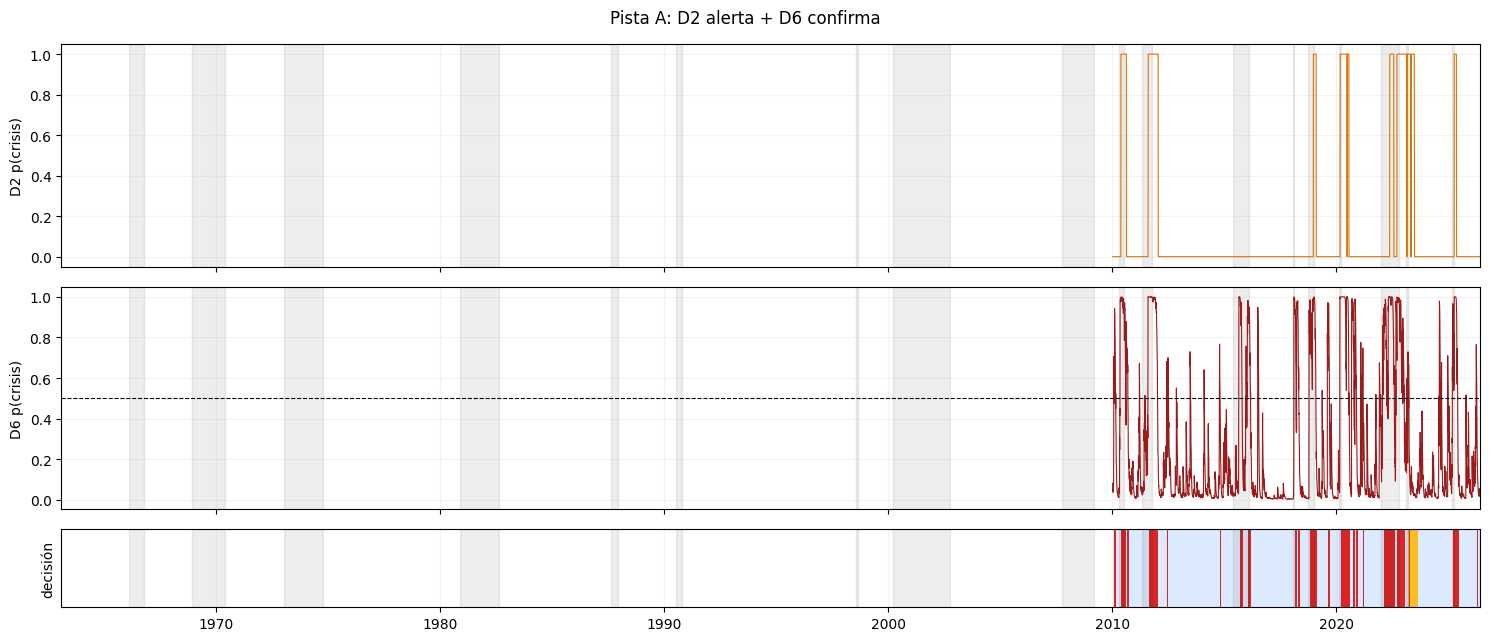

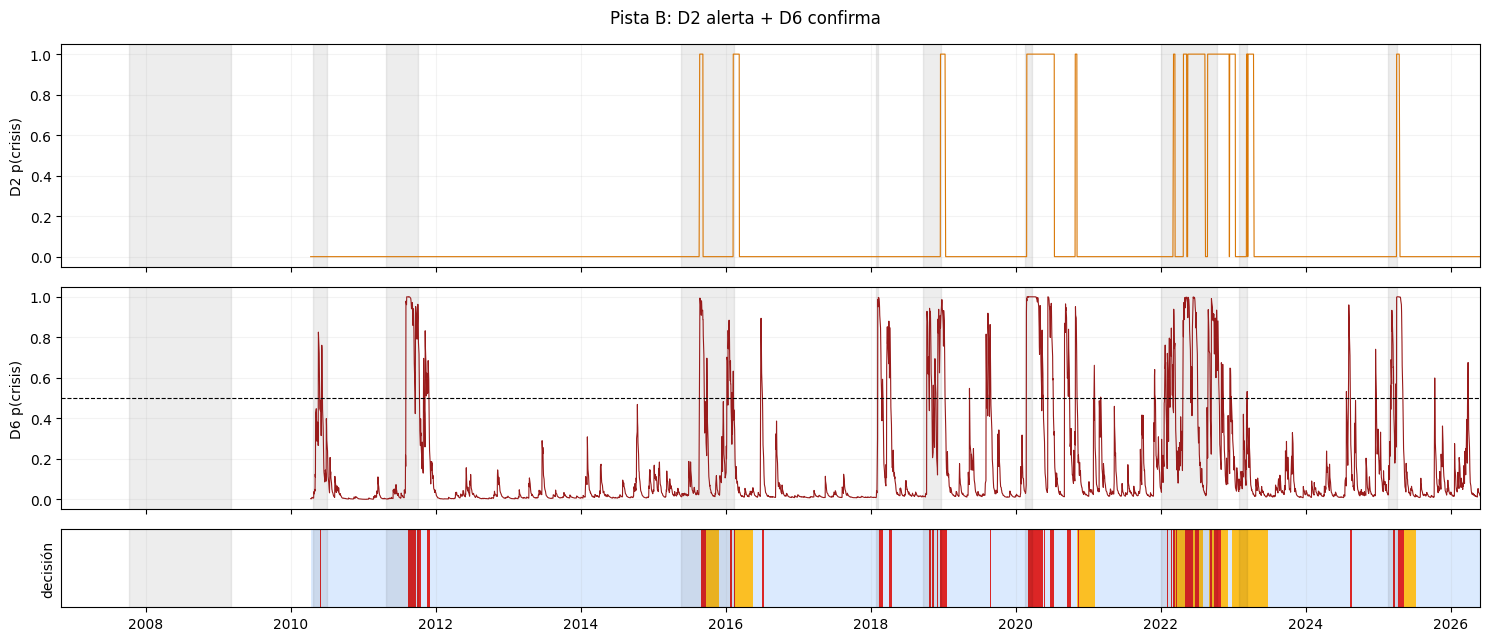

In [5]:
def plot_selected(track, frame):
    configure_evaluation(track)
    view = frame.loc[frame.index >= pd.Timestamp('2010-01-01')]
    colors = ListedColormap(['#dbeafe', '#fbbf24', '#dc2626'])
    fig, axes = plt.subplots(3, 1, figsize=(15, 6.5), sharex=True, gridspec_kw={'height_ratios': [2, 2, 0.7]})
    axes[0].plot(view.index, view['alert_probability'], color='#d97706', lw=0.8)
    axes[0].set_ylabel('D2 p(crisis)')
    axes[1].plot(view.index, view['confirmation_probability'], color='#991b1b', lw=0.8)
    axes[1].axhline(CONFIG.confirmation_threshold, color='black', ls='--', lw=0.8)
    axes[1].set_ylabel('D6 p(crisis)')
    axes[2].imshow(view['decision_code'].to_numpy()[None, :], aspect='auto', interpolation='nearest', cmap=colors, vmin=0, vmax=2, extent=[mdates.date2num(view.index[0]), mdates.date2num(view.index[-1]), 0, 1])
    axes[2].set_yticks([]); axes[2].set_ylabel('decisión'); axes[2].xaxis_date()
    for ax in axes:
        for start, end in ev.CRISIS_WINDOWS.values():
            ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='black', alpha=0.07)
        ax.grid(alpha=0.15)
    fig.suptitle(f'Pista {track}: D2 alerta + D6 confirma')
    fig.tight_layout(); plt.show()

for track in TRACKS:
    plot_selected(track, pair_frames[('D2+D6', track)])

## Conclusión

D2+D6 es la propuesta más sólida de esta ronda: conserva un confirmador con estabilidad cercana al 100%, produce avisos previos utilizables en ambas pistas y mejora el balance operativo frente a D7+D8 y D7+D6. La ganancia no debe interpretarse como evidencia de rentabilidad: el siguiente paso correcto es congelar esta regla y someterla a pseudolive o a un bloque temporal no usado en la selección.

In [6]:
selection.to_csv(OUTPUT / 'alert_selection.csv')
candidate_detail.to_csv(OUTPUT / 'alert_selection_by_track.csv', index=False)
comparison.to_csv(OUTPUT / 'pair_warning_comparison.csv', index=False)
pair_scores.to_csv(OUTPUT / 'pair_event_comparison.csv', index=False)
episodes.to_csv(OUTPUT / 'warning_episodes.csv', index=False)
sensitivity.to_csv(OUTPUT / 'sensitivity.csv', index=False)
sorted(path.name for path in OUTPUT.glob('*.csv'))

['alert_selection.csv',
 'alert_selection_by_track.csv',
 'pair_event_comparison.csv',
 'pair_warning_comparison.csv',
 'sensitivity.csv',
 'warning_episodes.csv']